# 🎭 Detección de Puntos Clave Faciales con MediaPipe

**Materiales desarrollados por Matías Barreto, 2026**  
**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**  
* **Nomenclatura Oficial:** Procesamiento Digital de Imágenes  
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital  

---

## Objetivo

En este notebook vamos a detectar los **478 puntos clave** del rostro humano usando MediaPipe Face Mesh de Google. Vamos a trabajar sobre imágenes estáticas: cargar una foto, procesarla con el modelo y visualizar los landmarks dibujados sobre la imagen.

## Al terminar este material vamos a poder:

1. Explicar qué son los landmarks faciales y cuáles son sus aplicaciones reales.
2. Configurar y usar el detector Face Mesh de MediaPipe.
3. Convertir coordenadas normalizadas a posiciones en píxeles.
4. Visualizar los resultados de la detección sobre la imagen original.

## Microglosario

Antes de escribir código, definimos los términos que vamos a usar.

| Término | Definición | Analogía |
|---|---|---|
| **Landmark / Punto clave** | Coordenada (x, y, z) que representa un punto anatómico específico del rostro | Como los pines numerados en un mapa turístico: cada uno marca un lugar con nombre propio |
| **Face Mesh** | Red de 478 puntos distribuidos por todo el rostro que forman una malla geométrica | Como el alambrado de una escultura antes de aplicar el yeso: define la estructura tridimensional |
| **Coordenada normalizada** | Valor entre 0.0 y 1.0 que indica posición relativa independientemente del tamaño de la imagen | Como los porcentajes: 50% del ancho siempre es el centro, sin importar si la imagen mide 100 o 4000 píxeles |
| **BGR / RGB** | Dos formas de ordenar los canales de color de una imagen: Azul-Verde-Rojo (OpenCV) o Rojo-Verde-Azul (MediaPipe) | Como leer una lista de atrás para adelante: el contenido es el mismo, pero el orden cambia el significado |
| **`static_image_mode`** | Parámetro que le indica al modelo si va a procesar una imagen fija o cuadros de un video | Como avisarle al fotógrafo si va a sacar una foto de retrato o grabar un partido: cambia cómo prepara el equipo |

## ✦ Paso manual: de coordenada normalizada a píxel

Antes de ver el código, hagamos el cálculo a mano para entender qué hace el modelo con cada punto que detecta.

Supongamos que tenemos una imagen de **200 × 160 píxeles** y MediaPipe detecta la punta de la nariz en la posición normalizada `x = 0.50`, `y = 0.45`:

```
pixel_x = int(0.50 × 200) = int(100.0) = 100   ← mitad del ancho
pixel_y = int(0.45 × 160) = int(72.0)  =  72   ← un poco por encima del centro
```

Eso significa que el círculo verde se va a dibujar en la columna 100, fila 72.

El mismo cálculo se repite **478 veces** — una por cada landmark del Face Mesh. El código que vamos a ver más adelante hace exactamente eso en un bucle:

```python
coord_x_pixel = int(punto.x * ancho)
coord_y_pixel = int(punto.y * alto)
```

La normalización permite que el modelo funcione igual con una foto de celular de 720 píxeles y con una imagen de cámara profesional de 6000 píxeles.

## 1. Introducción: ¿Qué son los Landmarks Faciales?

### Una analogía simple

Imaginemos que queremos dibujar un retrato de alguien. ¿Qué puntos nos ayudarían a capturar mejor el rostro?

- Las esquinas de los ojos
- La punta de la nariz
- Las comisuras de los labios
- El contorno de la mandíbula
- Las cejas

Los **Landmarks Faciales** son exactamente eso: un conjunto de puntos específicos que "marcan" las características más importantes de un rostro.

### Definición técnica

Los landmarks faciales son **coordenadas (x, y, z)** de puntos clave predefinidos que representan características anatómicas de un rostro humano en una imagen digital.

Podemos pensarlos como un **mapa de ruta** que describe la geometría de una cara.

![MediaPipe Face Mesh](https://ai.google.dev/static/mediapipe/images/solutions/face_landmarker_keypoints.png?hl=es-419)

*Imagen: MediaPipe detecta 478 puntos en un rostro*

---

## 2. Aplicaciones en el Mundo Real

¿Por qué es importante detectar estos puntos? Acá hay algunos ejemplos cotidianos:

### Aplicaciones que usamos todos los días

1. **Filtros de Instagram y Snapchat**
   - Esos filtros que nos ponen orejas de perro o coronas de flores usan landmarks para saber exactamente dónde está la cara
   - Necesitan ubicar tus ojos, nariz y boca para colocar los efectos correctamente

2. **Face ID (desbloqueo facial)**
   - El celular analiza los landmarks del rostro para reconocer a su dueño
   - Compara la posición de los rasgos faciales con los datos guardados

3. **Videoconferencias con fondos virtuales**
   - Zoom, Teams y Meet detectan tu rostro para separarte del fondo
   - Usan landmarks para mantener tu cara siempre nítida mientras cambian el fondo

### Aplicaciones profesionales

| Área | Aplicación | Ejemplo |
|------|------------|----------|
| **Entretenimiento** | Animación facial para películas | Avatar, The Mandalorian |
| **Salud** | Detección de parálisis facial | Diagnóstico médico temprano |
| **Seguridad** | Reconocimiento facial | Aeropuertos, control de acceso |
| **Marketing** | Análisis de expresiones | Estudios de UX (experiencia de usuario) |
| **Gaming** | Control por gestos faciales | Juegos de realidad virtual |

---

## 3. Herramientas que Vamos a Usar

Para este ejercicio necesitamos dos bibliotecas principales:

### MediaPipe (Google)

**¿Qué es?** Una biblioteca de Google que nos da soluciones listas para usar en visión por computadora.

**¿Qué hace en este caso?** Detecta automáticamente 478 puntos en un rostro usando un modelo de inteligencia artificial ya entrenado.

**Analogía**: Es como tener un asistente experto que ya aprendió a reconocer rostros. No necesitamos entrenar nada, solo usarlo.

**Sitio oficial**: [MediaPipe Face Landmarker](https://ai.google.dev/edge/mediapipe/solutions/vision/face_landmarker)

### OpenCV (cv2)

**¿Qué es?** La biblioteca estándar para procesamiento de imágenes en Python.

**¿Qué hace en este caso?**
- Carga imágenes desde archivos
- Convierte entre diferentes formatos de color
- Dibuja círculos y líneas sobre las imágenes
- Muestra las imágenes procesadas

**Analogía**: Es como Photoshop, pero para programadores.

---

## 4. Paso 1: Instalación de Bibliotecas

### ¿Qué vamos a hacer?

Vamos a instalar las bibliotecas necesarias para trabajar con imágenes y detectar rostros.

### Nota importante sobre el símbolo `!`

Cuando vemos `!` al principio de una línea en el notebook, significa que estamos ejecutando un **comando de terminal**, no código Python.

Es como abrir la consola de la computadora y escribir un comando.

### ¿Por qué dos instalaciones?

1. **Primera línea**: Actualizamos `numpy` (biblioteca de cálculos matemáticos)
2. **Segunda línea**: Instalamos `mediapipe` y `opencv-python`

### Advertencia

Es normal que aparezcan algunos mensajes en rojo (warnings). No hay que preocuparse; si al final dice "Successfully installed", todo está bien.

---

In [2]:
# Instala las dependencias del notebook en el kernel activo.
# mediapipe 0.10.13+ (Tasks API) para Python 3.12; opencv-python-headless evita conflictos con Qt.
%pip install mediapipe opencv-python-headless numpy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Confirma qué intérprete de Python está activo en este kernel.
import sys
print(sys.executable)

c:\Proyectos\rodriguez-carmen-pdi-1c-2026\.venv_vision_aplicada\Scripts\python.exe


## 5. Paso 2: Importar las Bibliotecas

### ¿Qué significa "importar"?

**Analogía**: Es como abrir las cajas de herramientas que acabamos de instalar.

Tener las bibliotecas instaladas no alcanza, necesitamos "activarlas" en nuestro código con el comando `import`.

### Las importaciones principales

1. **`cv2`**: El nombre corto de OpenCV (versión 2)
2. **`mediapipe as mp`**: MediaPipe, renombrado como `mp` para escribir menos
3. **`mp_python` y `mp_vision`**: Módulos de la Tasks API que reemplazan a la antigua `mp.solutions`
4. **`matplotlib.pyplot`**: Para visualizar imágenes directamente en el notebook

### ¿Por qué usamos alias (`as`)?

`from mediapipe.tasks import python as mp_python` nos permite escribir `mp_python.BaseOptions(...)` en lugar del nombre completo cada vez.

Es como usar el apodo de alguien en lugar de su nombre completo.

---

In [4]:
# =============================================================================
# Verificación del entorno de trabajo para detección de puntos clave faciales.
# Se importan las bibliotecas necesarias y se confirman sus versiones antes de
# ejecutar cualquier procesamiento, garantizando compatibilidad entre módulos.
# =============================================================================

import mediapipe as mp
# Submódulo de la Tasks API (disponible desde MediaPipe 0.10.13):
# expone las clases base para configurar tareas (BaseOptions, etc.)
from mediapipe.tasks import python as mp_python
# Submódulo de visión de la Tasks API: contiene FaceLandmarker y otros
# detectores listos para usar sin construir grafos manualmente.
from mediapipe.tasks.python import vision as mp_vision

import cv2          # Lectura, escritura y manipulación de imágenes/video.
import numpy as np  # Operaciones matriciales sobre los arrays de píxeles.
import matplotlib.pyplot as plt  # Visualización de imágenes y resultados.

# Capturar las versiones instaladas permite detectar incompatibilidades
# entre builds (p. ej. MediaPipe requiere NumPy < 2.x en ciertas versiones).
version_mediapipe = mp.__version__
version_opencv    = cv2.__version__
version_numpy     = np.__version__

print("✓ Entorno listo.")
print(f"  mediapipe  {version_mediapipe}")
print(f"  opencv     {version_opencv}")
print(f"  numpy      {version_numpy}")
print("✓ Bibliotecas cargadas correctamente.")
print("  Estamos listos para empezar.")


✓ Entorno listo.
  mediapipe  0.10.35
  opencv     4.13.0
  numpy      2.4.6
✓ Bibliotecas cargadas correctamente.
  Estamos listos para empezar.


## 6. Paso 3: Descargar una Imagen de Prueba

### ¿Por qué necesitamos una imagen?

Para detectar landmarks faciales, necesitamos una foto de un rostro. Podemos usar:
- La imagen que descargamos automáticamente
- Una foto propia
- Cualquier imagen de internet con un rostro visible

### Cómo usar una imagen propia (opcional)

1. Copiá tu foto en la misma carpeta donde está este notebook
2. Cambiá `ruta_imagen` en el código abajo por el nombre de tu archivo

### Recomendaciones para la imagen

- **Rostro visible**: Que se vea la cara completa (no de perfil)
- **Buena iluminación**: Evitá fotos muy oscuras
- **Un solo rostro**: Para este ejercicio, es mejor empezar con una sola persona
- **Tamaño moderado**: No hace falta que sea gigante (menos de 5MB está bien)

### ¿Qué hace este código?

1. Define la URL de una imagen de ejemplo
2. Intenta descargarla desde internet
3. La guarda con el nombre `rostro_ejemplo.jpg`
4. Si falla, te da instrucciones para subir tu propia foto

---

In [5]:
# Descarga una imagen de ejemplo desde Unsplash (licencia libre).
# Para usar una foto propia: copiá el archivo a esta carpeta y cambiá ruta_imagen.

#import urllib.request


#ruta_imagen = "nosotras.jpg"



In [6]:
# Descarga una imagen de ejemplo desde Unsplash (licencia libre).
# Para usar una foto propia: copiá el archivo a esta carpeta y cambiá ruta_imagen.

import urllib.request


ruta_imagen = "xavi_y_yo.jpg"

## 7. Paso 4: Cargar y Preparar la Imagen

### ¿Qué vamos a hacer en este paso?

1. **Cargar la imagen** desde el archivo a la memoria de la computadora
2. **Verificar** que se cargó correctamente
3. **Convertir el formato de color** para que MediaPipe pueda procesarla

### Concepto importante: RGB vs BGR

Las computadoras representan colores mezclando Rojo, Verde y Azul (como un pintor mezcla pinturas).

**El problema**: Diferentes bibliotecas usan diferentes órdenes:
- **OpenCV usa BGR** (Azul, Verde, Rojo) - por razones históricas
- **MediaPipe usa RGB** (Rojo, Verde, Azul) - el orden más común

**Analogía**: Es como si un libro estuviera escrito de derecha a izquierda y otro de izquierda a derecha. El contenido es el mismo, pero hay que "traducir" el orden.

Por eso necesitamos convertir con `cv2.cvtColor()`.

### ¿Qué son las "dimensiones" de una imagen?

Una imagen digital es una cuadrícula de puntos (píxeles). Las dimensiones nos dicen:
- **Ancho**: cuántos píxeles tiene de izquierda a derecha
- **Alto**: cuántos píxeles tiene de arriba a abajo

Por ejemplo: 1920 × 1080 significa 1920 píxeles de ancho y 1080 de alto.

---

In [7]:
# =============================================================================
# Carga la imagen desde ruta_imagen, verifica que exista y la convierte de
# BGR a RGB. OpenCV lee imágenes en BGR por convención histórica, pero
# MediaPipe (y la mayoría de las bibliotecas modernas de visión) esperan RGB.
# =============================================================================

print("=" * 50)
print("CARGANDO Y PREPARANDO LA IMAGEN")
print("=" * 50)
print()

imagen = cv2.imread(ruta_imagen)  # Retorna None si la ruta no existe o es inválida.

# Guard clause: detener el flujo temprano evita errores crípticos más adelante
# (p. ej. AttributeError al intentar acceder a .shape sobre None).
if imagen is None:
    print(f"✗ No se pudo cargar '{ruta_imagen}'")
    print("  Verificá que el archivo esté en la misma carpeta que este notebook.")

else:
    print("✓ Imagen cargada exitosamente.")
    print()

    # .shape devuelve la tupla (alto, ancho, canales); se desempaqueta por
    # claridad en lugar de usar índices directos en los prints que siguen.
    alto    = imagen.shape[0]  # Número de filas de píxeles.
    ancho   = imagen.shape[1]  # Número de columnas de píxeles.
    canales = imagen.shape[2]  # 3 en BGR; útil para detectar imágenes en escala de grises (1 canal).

    print(f"  Ancho:   {ancho} píxeles")
    print(f"  Alto:    {alto} píxeles")
    print(f"  Canales: {canales} (formato BGR de OpenCV)")
    print()

    # COLOR_BGR2RGB invierte el orden de los canales (B↔R); no copia datos
    # innecesariamente: es una operación liviana sobre el array de píxeles.
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

    print("✓ Conversión de formato completada: BGR → RGB")
    print("  La imagen está lista para MediaPipe.")


CARGANDO Y PREPARANDO LA IMAGEN

✓ Imagen cargada exitosamente.

  Ancho:   2320 píxeles
  Alto:    1740 píxeles
  Canales: 3 (formato BGR de OpenCV)

✓ Conversión de formato completada: BGR → RGB
  La imagen está lista para MediaPipe.


## 8. Paso 5: Configurar el Detector de MediaPipe

### ¿Qué vamos a hacer?

Vamos a crear y configurar el detector usando la **Tasks API** de MediaPipe (versión 0.10.13+). Esta API reemplaza a la antigua `mp.solutions.face_mesh` y requiere un archivo de modelo que se descarga automáticamente la primera vez.

### ¿Por qué la Tasks API?

MediaPipe 0.10.13 (la versión disponible para Python 3.12) eliminó la API anterior (`mp.solutions`). La Tasks API funciona igual conceptualmente, pero con nombres de parámetros y estructura de resultados distintos.

### Comparación entre APIs

| API anterior (`mp.solutions`) | Tasks API (la que usamos) |
|-------------------------------|---------------------------|
| `mp.solutions.face_mesh` | `mp_vision.FaceLandmarker` |
| `static_image_mode=True` | No se necesita (modo estático por defecto) |
| `max_num_faces=1` | `num_faces=1` |
| `refine_landmarks=True` | No se necesita (478 puntos por defecto) |
| `min_detection_confidence` | `min_face_detection_confidence` |
| `.process(imagen_rgb)` | `.detect(mp.Image(...))` |
| `resultados.multi_face_landmarks` | `resultados.face_landmarks` |

### Parámetros que usamos

#### `num_faces=1`

Buscá como máximo 1 rostro. Cambialo a 2 o más si tu imagen tiene varias personas.

#### `min_face_detection_confidence=0.5`

Confianza mínima para aceptar una detección. Escala de 0.0 a 1.0.

- `0.5` — nivel medio, balancea precisión y flexibilidad
- `0.8` — muy estricto, solo rostros muy claros
- `0.3` — permisivo, detecta rostros en condiciones difíciles

### ¿Qué es el archivo `.task`?

La Tasks API necesita un modelo preentrenado en formato `.task` (aprox. 5 MB). El código lo descarga automáticamente la primera vez y lo guarda en la carpeta del notebook.

---

In [8]:
# =============================================================================
# Descarga el modelo TFLite empaquetado (.task), configura el detector con la
# Tasks API y ejecuta la detección de landmarks faciales sobre imagen_rgb.
# El modelo se descarga una sola vez; en ejecuciones posteriores se reutiliza
# el archivo local para evitar tráfico de red innecesario.
# =============================================================================

import os
import urllib.request

print("=" * 50)
print("CONFIGURANDO EL DETECTOR DE LANDMARKS")
print("=" * 50)
print()

modelo_path = "face_landmarker.task"  # Archivo bundle TFLite con pesos + metadatos del modelo.

# Descarga condicional: si el archivo ya existe en disco se omite la descarga.
# El modelo float16 pesa ~5 MB; es una versión cuantizada que equilibra
# velocidad y precisión respecto al modelo float32 completo.
if not os.path.exists(modelo_path):
    print("Descargando modelo de detección facial (aprox. 5 MB)...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
        modelo_path
    )
    print("✓ Modelo descargado.")
else:
    print(f"✓ Modelo ya disponible: {modelo_path}")
print()

# BaseOptions desacopla la configuración del runtime (ruta del modelo)
# de los parámetros específicos de la tarea, siguiendo el diseño de la Tasks API.
base_options = mp_python.BaseOptions(model_asset_path=modelo_path)

# FaceLandmarkerOptions define el comportamiento del detector:
#   num_faces=1                   → optimiza el pipeline para un solo rostro
#   min_face_detection_confidence → descarta detecciones por debajo del 50 %
#                                   de confianza para reducir falsos positivos
opciones = mp_vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=2,  # ← cambiá 1 por la cantidad máxima esperada
    min_face_detection_confidence=0.5
)

# create_from_options compila el grafo de inferencia y carga los pesos en
# memoria; es la operación más costosa del bloque, por eso se hace una vez.
detector_facial = mp_vision.FaceLandmarker.create_from_options(opciones)

print("✓ Detector inicializado.")
print("  Rostros máximos:  2")
print("  Confianza mínima: 50%")
print()

# mp.Image envuelve el array NumPy en el tipo que espera la Tasks API.
# ImageFormat.SRGB indica que los canales están en orden R-G-B (ya convertidos
# desde BGR en la celda anterior).
imagen_mp  = mp.Image(image_format=mp.ImageFormat.SRGB, data=imagen_rgb)
resultados = detector_facial.detect(imagen_mp)

detector_facial.close()  # Libera el grafo y los recursos de memoria del modelo.

print("✓ Procesamiento completado.")
print("  Los resultados están guardados en la variable 'resultados'.")


CONFIGURANDO EL DETECTOR DE LANDMARKS

✓ Modelo ya disponible: face_landmarker.task

✓ Detector inicializado.
  Rostros máximos:  2
  Confianza mínima: 50%

✓ Procesamiento completado.
  Los resultados están guardados en la variable 'resultados'.


## 9. Paso 6: Dibujar los Landmarks sobre la Imagen

### ¿Qué vamos a hacer?

Ahora viene la parte visual: vamos a dibujar círculos verdes en cada uno de los 478 puntos detectados.

### Conceptos importantes

#### 1. Coordenadas normalizadas vs coordenadas de píxeles

MediaPipe nos da coordenadas **normalizadas**: valores entre 0 y 1.

**¿Por qué normalizar?**  
Para que funcione con cualquier tamaño de imagen.

**Ejemplo:**
- Coordenada normalizada: `x = 0.5` (significa "en la mitad horizontalmente")
- Si la imagen tiene 1000 píxeles de ancho: `0.5 × 1000 = 500` píxeles
- Si la imagen tiene 2000 píxeles de ancho: `0.5 × 2000 = 1000` píxeles

**Fórmula de conversión:**
```
coord_x_pixel = coord_x_normalizada × ancho_imagen
coord_y_pixel = coord_y_normalizada × alto_imagen
```

#### 2. Sistema de coordenadas

```
(0,0) -----------> X (ancho)
  |
  |
  |
  v
  Y (alto)
```

- El punto (0,0) está en la **esquina superior izquierda**
- X aumenta hacia la derecha
- Y aumenta hacia abajo (¡al revés de matemática!)

#### 3. La función `cv2.circle()`

Esta función dibuja un círculo en una imagen.

**Sintaxis:**
```python
cv2.circle(
    imagen,          # Dónde dibujar
    (x, y),          # Centro del círculo (tupla con coordenadas)
    radio,           # Tamaño del círculo en píxeles
    (B, G, R),       # Color en formato BGR
    grosor           # Grosor del borde (-1 = relleno completo)
)
```

**Nuestros valores:**
- Radio: `2` píxeles (círculos pequeños)
- Color: `(0, 255, 0)` = verde en BGR
- Grosor: `-1` = círculo completamente relleno

#### 4. ¿Por qué hacemos una copia de la imagen?

```python
imagen_con_puntos = imagen.copy()
```

Si modificamos `imagen` directamente, perdemos la original. Con `.copy()` creamos una versión duplicada que podemos modificar sin afectar el original.

**Analogía**: Es como hacer una fotocopia para escribir sobre ella, manteniendo el original intacto.

### Flujo del código

```
1. Crear copia de la imagen
   ↓
2. ¿Se detectaron rostros?
   ↓ SÍ
3. Tomar el primer rostro
   ↓
4. Para cada uno de los 478 puntos:
   → Convertir coordenadas normalizadas a píxeles
   → Dibujar círculo verde
   ↓
5. Mostrar imagen resultante
```

---

DIBUJANDO LANDMARKS EN LA IMAGEN

Dimensiones de trabajo: 2320 × 1740 píxeles

✓ 2 rostro(s) detectado(s).

  Rostro 1: 478 landmarks — color (0, 255, 0) (BGR)
  Rostro 2: 478 landmarks — color (255, 80, 0) (BGR)

✓ 956 puntos dibujados en total (2 rostro(s)).



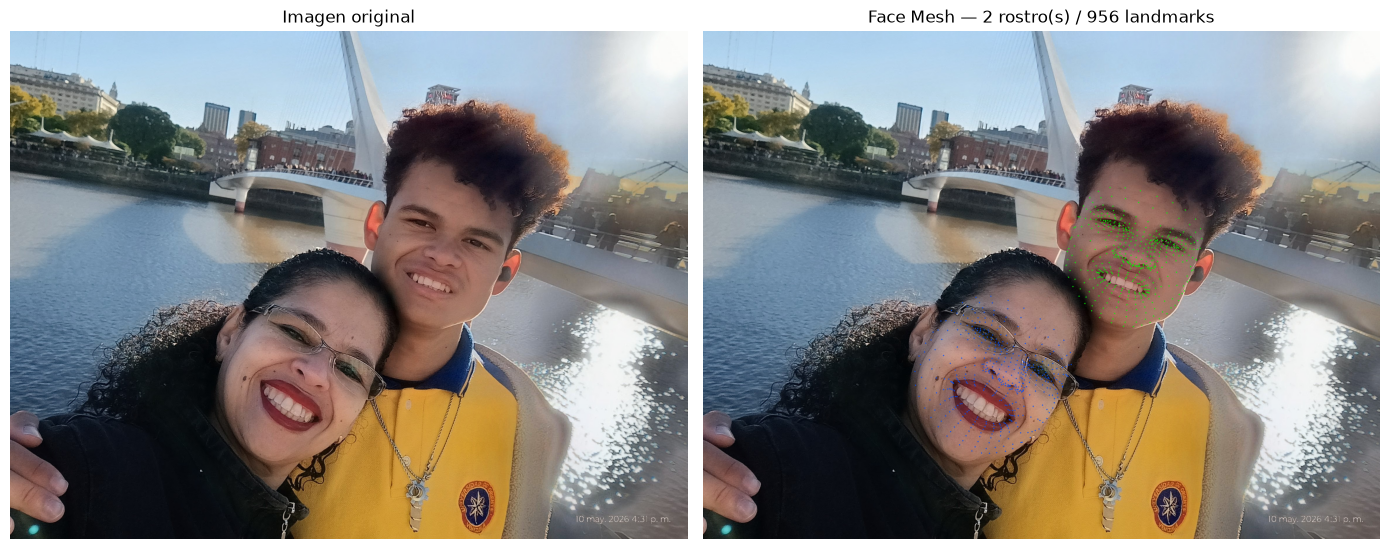

Leyenda:
  Cada color representa un rostro distinto.
  Los 478 puntos por rostro están distribuidos por ojos, nariz, boca, frente y mandíbula.


In [9]:
# =============================================================================
# Convierte las coordenadas normalizadas de los landmarks al espacio de píxeles
# y los dibuja como círculos sobre una copia de la imagen original.
# Finalmente muestra un panel comparativo: imagen original vs. imagen anotada.
# =============================================================================

print("=" * 50)
print("DIBUJANDO LANDMARKS EN LA IMAGEN")
print("=" * 50)
print()

# Se trabaja sobre una copia para preservar la imagen original intacta;
# cv2.circle modifica el array en memoria (operación in-place).
imagen_con_puntos = imagen.copy()

alto  = imagen.shape[0]  # filas de píxeles
ancho = imagen.shape[1]  # columnas de píxeles

print(f"Dimensiones de trabajo: {ancho} × {alto} píxeles")
print()

# face_landmarks es una lista vacía si no se detectó ningún rostro,
# por lo que evalúa como False en Python (truthy check).
if resultados.face_landmarks:

    # CAMBIO: cantidad de rostros detectados (antes era siempre 1).
    cantidad_rostros   = len(resultados.face_landmarks)#Antes se asumía 1 rostro; ahora se cuenta cuántos hay.
    total_landmarks    = 0

    print(f"✓ {cantidad_rostros} rostro(s) detectado(s).")
    print()

    # Un color distinto por rostro para distinguirlos visualmente en BGR.
    colores_por_rostro = [(0, 255, 0), (255, 80, 0), (0, 80, 255)]

    # CAMBIO: en lugar de acceder solo a [0], se itera sobre todos los
    # rostros detectados con enumerate para obtener el índice de cada uno.
    for indice_rostro, lista_landmarks in enumerate(resultados.face_landmarks):#Reemplaza el acceso fijo a [0]; itera sobre todos los rostros.
        cantidad_landmarks  = len(lista_landmarks)
        total_landmarks    += cantidad_landmarks
        # El módulo (%) garantiza que el índice de color no supere el largo
        # de la lista aunque haya más rostros que colores definidos.
        color = colores_por_rostro[indice_rostro % len(colores_por_rostro)]#Permite distinguir visualmente cada rostro en la imagen final.

        print(f"  Rostro {indice_rostro + 1}: {cantidad_landmarks} landmarks — color {color} (BGR)")

        for punto in lista_landmarks:
            # MediaPipe devuelve coordenadas normalizadas relativas al tamaño de
            # la imagen; multiplicar por ancho/alto las convierte a píxeles enteros.
            coord_x_pixel = int(punto.x * ancho)
            coord_y_pixel = int(punto.y * alto)

            cv2.circle(
                imagen_con_puntos,
                (coord_x_pixel, coord_y_pixel),
                2,      # radio pequeño para no tapar los puntos vecinos
                color,  # CAMBIO: color variable por rostro (antes fijo en verde)
                -1      # grosor -1 = relleno sólido en lugar de contorno
            )

    print()
    print(f"✓ {total_landmarks} puntos dibujados en total ({cantidad_rostros} rostro(s)).")
    print()

    # Nueva conversión BGR→RGB necesaria porque imagen_con_puntos heredó el
    # formato BGR de OpenCV; imshow de matplotlib espera RGB.
    imagen_para_mostrar = cv2.cvtColor(imagen_con_puntos, cv2.COLOR_BGR2RGB)

    # Panel 1×2: comparación lado a lado entre original y anotada.
    # figsize=(14, 6) da espacio suficiente para ver los puntos con detalle.
    figura, eje = plt.subplots(1, 2, figsize=(14, 6))

    eje[0].imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    eje[0].set_title("Imagen original")
    eje[0].axis("off")  # Oculta ejes y ticks; no aportan información en imágenes.

    eje[1].imshow(imagen_para_mostrar)
    # CAMBIO: el título ahora refleja la cantidad real de rostros procesados.
    eje[1].set_title(f"Face Mesh — {cantidad_rostros} rostro(s) / {total_landmarks} landmarks")
    eje[1].axis("off")

    plt.tight_layout()  # Ajusta márgenes automáticamente para evitar solapamiento de títulos.
    plt.show()

    print("Leyenda:")
    print("  Cada color representa un rostro distinto.")
    print("  Los 478 puntos por rostro están distribuidos por ojos, nariz, boca, frente y mandíbula.")

else:
    print("✗ No se detectó ningún rostro en la imagen.")
    print()
    print("Posibles causas:")
    print("  - El rostro está de perfil o muy inclinado")
    print("  - La imagen está muy oscura o borrosa")
    print("  - El rostro es muy pequeño dentro de la imagen")
    print()
    print("Sugerencias:")
    print("  - Probá con otra imagen de frente y buena iluminación")
    print("  - Bajá min_face_detection_confidence a 0.3 en la celda anterior")



## 10. Reflexión y Conclusiones

### ¿Qué acabamos de hacer?

En este notebook completamos un flujo completo de visión por computadora:

1. **Instalación de herramientas** (MediaPipe, OpenCV)
2. **Carga de imagen** desde internet o archivo local
3. **Preprocesamiento** (conversión de formato de color)
4. **Detección con IA** (modelo pre-entrenado de MediaPipe)
5. **Visualización de resultados** (dibujado de landmarks)

### Lo que aprendimos

**Conceptos técnicos:**
- Qué son los landmarks faciales y sus aplicaciones
- Diferencia entre coordenadas normalizadas y píxeles
- Formatos de color (RGB vs BGR)
- Uso de modelos pre-entrenados

**Habilidades prácticas:**
- Usar bibliotecas de Python (importar y configurar)
- Trabajar con imágenes en código
- Interpretar y visualizar resultados de IA
- Debugging básico (qué hacer si algo falla)

### Próximos pasos

Ahora que tenés los landmarks, podés:

**Nivel básico:**
- Cambiar el color o tamaño de los puntos
- Probar con diferentes fotos (tuyas, de familiares)
- Detectar múltiples rostros (cambiar `max_num_faces`)

**Nivel intermedio:**
- Medir distancias entre puntos (ej: ancho de la boca)
- Dibujar líneas conectando landmarks (crear una "malla")
- Detectar expresiones básicas (boca abierta/cerrada)

**Nivel avanzado:**
- Crear filtros tipo Snapchat (superponer imágenes)
- Analizar expresiones faciales automáticamente
- Trabajar con video en tiempo real
- Crear una aplicación web (Streamlit/Gradio)

### Recursos adicionales

**Documentación oficial:**
- [MediaPipe Face Landmarker](https://ai.google.dev/edge/mediapipe/solutions/vision/face_landmarker)
- [OpenCV Python Tutorials](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html)

**Tutoriales en video:**
- Buscá en YouTube: "MediaPipe Face Mesh tutorial"
- Canal recomendado: "Nicholas Renotte" (en inglés, con subtítulos)

### Desafío final

**Probá modificar el código para:**
1. Dibujar solo los landmarks de los ojos (landmarks 33, 133, 362, 263)
2. Usar diferentes colores para diferentes partes del rostro
3. Agregar texto con el número de cada landmark

**Pista**: Vas a necesitar usar condiciones (`if`) y la función `cv2.putText()` para el texto.

---

**¡Felicitaciones por completar este tutorial!**

Ahora entendés cómo funcionan tecnologías que usás todos los días (filtros de redes sociales, reconocimiento facial, etc.).

Este es el primer paso en el fascinante mundo de la visión por computadora.

---

## 11. Actividades Extras (Opcional)

### Actividad 1: Experimentar con los parámetros

Volvamos a la celda donde configuramos el detector y probemos cambiar:

```python
# Opción 1: Detectar hasta 3 rostros
num_faces=3

# Opción 2: Ser más permisivo con la detección
min_face_detection_confidence=0.3
```

**✎ Para pensar:**  
¿Cómo cambian los resultados con cada configuración?

---

### Actividad 2: Analizar las coordenadas

Agregamos este código en una nueva celda para ver las coordenadas del primer landmark:

```python
if resultados.face_landmarks:
    primer_punto = resultados.face_landmarks[0][0]
    print(f"Coordenadas del primer landmark:")
    print(f"  x (normalizada): {primer_punto.x:.4f}")
    print(f"  y (normalizada): {primer_punto.y:.4f}")
    print(f"  z (profundidad): {primer_punto.z:.4f}")
    print()
    print(f"  x (píxeles): {int(primer_punto.x * ancho)}")
    print(f"  y (píxeles): {int(primer_punto.y * alto)}")
```

**Pregunta para reflexionar:**  
¿Por qué las coordenadas normalizadas son útiles?

---

### Actividad 3: Contar landmarks por región

Investigá en la [documentación de MediaPipe](https://ai.google.dev/edge/mediapipe/solutions/vision/face_landmarker) cuáles son los rangos de índices para:
- Ojos
- Boca
- Contorno facial

Intentá crear un código que cuente cuántos landmarks hay en cada región.

---

### Actividad 4: Medir distancias

Usando el **Teorema de Pitágoras**, calculá la distancia entre dos puntos:

```python
import math

if resultados.face_landmarks:
    landmarks = resultados.face_landmarks[0]

    punto1 = landmarks[33]
    punto2 = landmarks[133]

    x1 = punto1.x * ancho
    y1 = punto1.y * alto
    x2 = punto2.x * ancho
    y2 = punto2.y * alto

    distancia = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    print(f"Distancia entre esquinas de los ojos: {distancia:.2f} píxeles")
```

**Desafío:**  
Calculá el ancho de la boca (distancia entre las comisuras de los labios).

---

## Referencias y Créditos

### Documentación oficial

- [MediaPipe Face Landmarker](https://ai.google.dev/edge/mediapipe/solutions/vision/face_landmarker?hl=es-419)
- [OpenCV Python Tutorials](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html)
- [Google Colab](https://colab.research.google.com/)

### Bibliotecas utilizadas

- **MediaPipe** - Google LLC (Apache License 2.0)
- **OpenCV** - OpenCV Team (Apache License 2.0)
- **NumPy** - NumPy Developers (BSD License)

### Imágenes de ejemplo

- Imagen de rostro: [Unsplash](https://unsplash.com/) (Licencia libre)

---

**Materiales desarrollados por Matías Barreto, 2026**  
**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**

---